In [1]:
import numpy as np
import random
from tqdm.notebook import trange, tqdm

In [57]:
with open('text8') as f:
    corpus = f.read()[:20000].split()

In [58]:
len(corpus)

3193

In [59]:
vocab = set(corpus)

len(vocab)

1036

In [60]:
word2i = {w: idx for idx, w in enumerate(vocab)}
i2word = {idx: w for idx, w in enumerate(vocab)}

In [61]:
word2i

{'advocates': 0,
 'culottes': 1,
 'wealth': 2,
 'wish': 3,
 'capitalism': 4,
 'yarros': 5,
 'seen': 6,
 'interfering': 7,
 'several': 8,
 'further': 9,
 'as': 10,
 'being': 11,
 'amidst': 12,
 'nestor': 13,
 'property': 14,
 'alliance': 15,
 'answers': 16,
 'supported': 17,
 'aiming': 18,
 'suppression': 19,
 'profits': 20,
 'party': 21,
 'man': 22,
 'laws': 23,
 'provide': 24,
 'strongly': 25,
 'mean': 26,
 'ruling': 27,
 'doctrine': 28,
 'successful': 29,
 'zapatista': 30,
 'how': 31,
 'periodical': 32,
 'overthrown': 33,
 'labor': 34,
 'file': 35,
 'cases': 36,
 'objective': 37,
 'bands': 38,
 'xiv': 39,
 'construct': 40,
 'labour': 41,
 'allow': 42,
 'commonly': 43,
 'time': 44,
 'lysander': 45,
 'destroy': 46,
 'accepted': 47,
 'although': 48,
 'bertrand': 49,
 'benjamin': 50,
 'nihilism': 51,
 'goldman': 52,
 'reality': 53,
 'communities': 54,
 'cnt': 55,
 'supporters': 56,
 'federations': 57,
 'controlled': 58,
 'use': 59,
 'de': 60,
 'possession': 61,
 'and': 62,
 'difference':

In [62]:
i2word

{0: 'advocates',
 1: 'culottes',
 2: 'wealth',
 3: 'wish',
 4: 'capitalism',
 5: 'yarros',
 6: 'seen',
 7: 'interfering',
 8: 'several',
 9: 'further',
 10: 'as',
 11: 'being',
 12: 'amidst',
 13: 'nestor',
 14: 'property',
 15: 'alliance',
 16: 'answers',
 17: 'supported',
 18: 'aiming',
 19: 'suppression',
 20: 'profits',
 21: 'party',
 22: 'man',
 23: 'laws',
 24: 'provide',
 25: 'strongly',
 26: 'mean',
 27: 'ruling',
 28: 'doctrine',
 29: 'successful',
 30: 'zapatista',
 31: 'how',
 32: 'periodical',
 33: 'overthrown',
 34: 'labor',
 35: 'file',
 36: 'cases',
 37: 'objective',
 38: 'bands',
 39: 'xiv',
 40: 'construct',
 41: 'labour',
 42: 'allow',
 43: 'commonly',
 44: 'time',
 45: 'lysander',
 46: 'destroy',
 47: 'accepted',
 48: 'although',
 49: 'bertrand',
 50: 'benjamin',
 51: 'nihilism',
 52: 'goldman',
 53: 'reality',
 54: 'communities',
 55: 'cnt',
 56: 'supporters',
 57: 'federations',
 58: 'controlled',
 59: 'use',
 60: 'de',
 61: 'possession',
 62: 'and',
 63: 'differen

In [63]:
sum = 0
countOfWord = [sum+1 for w in corpus]

In [64]:
unigramFrequencies = {w: corpus.count(w) for w in vocab}

In [65]:
weightedUnigramFrequencies = {}

In [66]:
for k, v in unigramFrequencies.items():
    weightedUnigramFrequencies[k] = (v ** 0.75) / (len(vocab) ** 0.75)

In [67]:
weightedUnigramFrequencies

{'advocates': 0.009209852613736361,
 'culottes': 0.005476211128190844,
 'wealth': 0.005476211128190844,
 'wish': 0.005476211128190844,
 'capitalism': 0.009209852613736361,
 'yarros': 0.005476211128190844,
 'seen': 0.005476211128190844,
 'interfering': 0.005476211128190844,
 'several': 0.005476211128190844,
 'further': 0.005476211128190844,
 'as': 0.09514578832158166,
 'being': 0.005476211128190844,
 'amidst': 0.005476211128190844,
 'nestor': 0.009209852613736361,
 'property': 0.03963475794146647,
 'alliance': 0.009209852613736361,
 'answers': 0.005476211128190844,
 'supported': 0.012483061912085314,
 'aiming': 0.005476211128190844,
 'suppression': 0.005476211128190844,
 'profits': 0.005476211128190844,
 'party': 0.005476211128190844,
 'man': 0.009209852613736361,
 'laws': 0.005476211128190844,
 'provide': 0.005476211128190844,
 'strongly': 0.009209852613736361,
 'mean': 0.005476211128190844,
 'ruling': 0.005476211128190844,
 'doctrine': 0.005476211128190844,
 'successful': 0.0054762111

In [68]:
def sigmoid(m):
  return (1 / (1 + np.e ** (-m)))

In [14]:
# def backwardLoss(t, c, n, targetWordI, contextWordsI, negativeSamplesI, lr):
#     d = (np.mean(np.sum((c @ t.reshape(32, 3, 1)), 1)))
#     s = sigmoid(d)
#     posDer = (s - 1) * t
#     posLoss = np.log(s)
#     d = -(np.mean(np.sum((n @ t.reshape(32, 3, 1)), 1)))
#     s = sigmoid(d)
#     negDer = s * t
#     negLoss = np.log(s)

#     #backprop
#     print('c from backwardLoss func reshaped removed zeros', c.reshape(128, 3)[~np.all(c.reshape(128, 3)==0, axis=1)].shape)
#     print('sigmoid partPosDer from backwardLoss', sigmoid(c @ t.reshape(32, 3, 1)))
#     partPosDer = (sigmoid(c @ t.reshape(32, 3, 1)) - 1)
#     partPosDer.reshape(128, 1)[np.all(partPosDer.reshape(128, 1)==-0.5, axis=1)] = \
#         np.repeat([[0]], partPosDer.reshape(128, 1)[np.all(partPosDer.reshape(128, 1)==-0.5, axis=1)].shape[0], axis=0)
#     print('part pos der finding',partPosDer)
#     print('full part pos der', (lr * partPosDer * t.reshape(32, 1, 3)).reshape(128, 3))
#     C[contextWordsI] -= (lr * partPosDer * t.reshape(32, 1, 3)).reshape(128, 3)
#     partNegDer = sigmoid(n @ t.reshape(32, 3, 1))
#     C[negativeSamplesI] -= (lr * partNegDer * t.reshape(32, 1, 3)).reshape(256, 3)
#     W[targetWordI] -= lr * ((partPosDer.reshape(32, 1, 4) @ c).squeeze(axis=1) + (partNegDer.reshape(32, 1, 8) @ n).squeeze(axis=1))

#     return -(posLoss + negLoss)

In [15]:
# d = c @ t.reshape(32, dim_size, 1)
# print(d.shape)
# s = sigmoid(d)
# print(s.shape)
# posLoss = np.mean(np.log(s))

# print(posLoss)

In [16]:
# def backwardLoss(t, c, n, targetWordI, contextWordsI, negativeSamplesI, lr, dim_size):
#     c_flat = c.reshape(-1, c.shape[2])
#     mask = np.all(c_flat == 0, axis=1)  # shape: (32,)
#     c_rows_with_all_zeros = np.nonzero(mask)[0]
#     n_flat = n.reshape(-1, n.shape[2])
#     mask = np.all(n_flat == 0, axis=1)  # shape: (32,)
#     n_rows_with_all_zeros = np.nonzero(mask)[0]
    
    
#     d = c @ t.reshape(32, dim_size, 1)
#     s = sigmoid(d)
#     partPosDer = (s - 1) * t.reshape(32, 1, dim_size)
#     posLoss = np.mean(np.log(s))
#     d = -n @ t.reshape(32, dim_size, 1)
#     s = sigmoid(d)
#     partNegDer = s * t.reshape(32, 1, dim_size)
#     negLoss = np.mean(np.log(s))
#     # print(f"part pos der, part neg der: {partPosDer}, {partNegDer}")
#     #backprop
#     C[contextWordsI] -= (lr * np.delete(partPosDer.reshape(-1, partPosDer.shape[2]), c_rows_with_all_zeros, axis=0))
#     C[negativeSamplesI] -= (lr * np.delete(partNegDer.reshape(-1, partNegDer.shape[2]), n_rows_with_all_zeros, axis=0))
#     W[targetWordI] -= (lr * ())
    
#     # c_flatten = c.reshape(128, dim_size)[~np.all(c.reshape(128, dim_size) == 0.0, axis=1)]
#     # partPosDer = sigmoid(c_flatten @ t.reshape(dim_size, 32)) - 1
#     # PosDer = (partPosDer @ t.reshape(32, dim_size)) * lr
#     # C[contextWordsI] -= PosDer
#     # n_flatten = n.reshape(256, dim_size)[~np.all(n.reshape(256, dim_size) == 0.0, axis=1)]
#     # partNegDer = sigmoid(n_flatten @ t.reshape(dim_size, 32))
#     # NegDer = (partNegDer @ t.reshape(32, dim_size)) * lr
#     # C[negativeSamplesI] -= NegDer
#     # W[targetWordI] -= (lr * ((partPosDer.T @ c_flatten) + (partNegDer.T @ n_flatten)))

#     return -(posLoss + negLoss)


In [17]:
# WINDOW_SIZE = 2
# K = 2
# words = list(weightedUnigramFrequencies.keys())
# weights = list(weightedUnigramFrequencies.values())

# def SGNS(choices, dim_size):
#     targetWord = []
#     contextWordsM = []
#     negativeSamplesM = []
#     targetWordI = []
#     contextWordsI = []
#     negativeSamplesI = []
#     for idx in choices:
#         contextWordsPadded = np.zeros((4, dim_size))
#         negativeSamplesPadded  = np.zeros((8, dim_size))
#         targetWordI += [word2i[corpus[idx]]]

        
#         targetWord.append(W[word2i[corpus[idx]]])
#         contextWords = corpus[max(idx-WINDOW_SIZE, 0):max(idx, 0)] \
#                                 + corpus[idx+1:idx+WINDOW_SIZE+1]
#         sliceRange = C[[word2i[w] for w in contextWords]].shape[0]
#         contextWordsPadded[:sliceRange] = C[[word2i[w] for w in contextWords]]
#         contextWordsM.append(contextWordsPadded)
#         contextWordsI += [word2i[w] for w in contextWords]
#         negativeSamples = random.choices(words, weights=weights, \
#                                          k=len(contextWords)*K)
#         sliceRange = C[[word2i[w] for w in negativeSamples]].shape[0]
#         negativeSamplesPadded[:sliceRange] = C[[word2i[w] for w in negativeSamples]]
#         negativeSamplesM.append(negativeSamplesPadded)
#         negativeSamplesI += [word2i[w] for w in negativeSamples]
#     targetWord = np.stack(targetWord, axis=0)
#     contextWordsM = np.stack(contextWordsM, axis=0)
#     negativeSamplesM = np.stack(negativeSamplesM, axis=0)
    

#     return targetWord, contextWordsM, negativeSamplesM, targetWordI, contextWordsI, negativeSamplesI


In [18]:
# EPOCHS = 100
# ITERS = int(len(corpus) / 32)
# WINDOW_SIZE = 2
# K = 2
# dim_size = 100
# words = list(weightedUnigramFrequencies.keys())
# weights = list(weightedUnigramFrequencies.values())
# C = np.random.randn(len(vocab), dim_size)
# W = np.random.randn(len(vocab), dim_size)
# lr = 1e-6
# total_loss = 0.0

# for e in range(EPOCHS):
#   total_loss = 0.0
#   for i in range(ITERS):
#     choices = np.random.choice(np.arange(len(corpus)), 32)
#     t, c, n, tI, cI, nI = SGNS(choices, dim_size)
#     L = backwardLoss(t, c, n, tI, cI, nI, lr, dim_size=dim_size)
#     total_loss += L
#   print(f'Epoch: {e+1} {total_loss/ITERS}')


In [69]:
WINDOW_SIZE = 2
K = 2
dim_size = 50
C = np.random.randn(len(vocab), dim_size)
W = np.random.randn(len(vocab), dim_size)
words = list(weightedUnigramFrequencies.keys())
weights = list(weightedUnigramFrequencies.values())
lr = 1e-3
running_loss = []
EPOCHS = 10000

pbar = tqdm(range(EPOCHS), desc="Training", unit="epoch")

for e in pbar:
    total_loss = 0.0
    for i, w in enumerate(corpus):
        #get target, context, negative samples
        t = w
        c = corpus[max(i-WINDOW_SIZE, 0):max(i, 0)] \
                                    + corpus[i+1:i+WINDOW_SIZE+1]
        n = random.choices(words, weights=weights, \
                                            k=len(c)*K)
        #get target, context, negative samples indices    
        tI = word2i[t]
        cI = [word2i[cw] for cw in c]
        nI = [word2i[nw] for nw in n]

        #get target, context, negaIve samples embeddings
        tE = W[tI]
        cE = C[cI]
        nE = C[nI]

        #calculate total loss
        pL = np.sum(np.log(sigmoid(cE @ tE)))
        nL = np.sum(np.log(sigmoid(-nE @ tE)))
        L = -(pL + nL)
        total_loss += L

        #derivaIve calculaIon
        lParDerC = (sigmoid(cE @ tE) - 1)
        lParDerN = (sigmoid(nE @ tE))
        lParDerT = np.sum(lParDerC[:, None] * cE, 0) + np.sum(lParDerN[:, None] * nE, 0)
        
        #backprop
        C[cI] -= lr * lParDerC[:, None] * tE
        C[nI] -= lr * lParDerN[:, None] * tE
        W[tI] -= lr * lParDerT
    avg_loss = total_loss / len(corpus)
    running_loss.append(avg_loss)
    pbar.set_postfix({"avg_loss": f"{avg_loss:.4f}"})
    # print(f"Epoch {e+1} Loss: {total_loss/len(corpus)}")
    # tqdm.write(f"Epoch {e+1} Avg Loss: {avg_loss:.4f}")


Training:   0%|          | 0/10000 [00:00<?, ?epoch/s]

KeyboardInterrupt: 

In [70]:
embedding_matrix = C + W

In [75]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
embeddings_2d = tsne.fit_transform(embedding_matrix)

# Plot
def viz_nearest_words(nearest_words: list):
    plt.figure(figsize=(12, 8))
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.7)

    # Optional: annotate a few points
    for i, word in enumerate(nearest_words):  # annotate only first 50 for clarity
        plt.annotate(word, (embeddings_2d[word2i[word], 0], embeddings_2d[word2i[word], 1]))

    plt.title("t-SNE projection of Embeddings")
    plt.show()


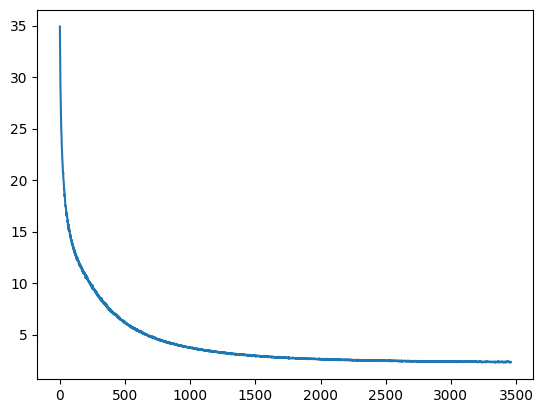

In [71]:
plt.plot(running_loss)

In [78]:
def top_nearest_words(source_word: str, num: int):
    norms = np.linalg.norm(embedding_matrix, axis=1, keepdims=True)
    normalized_matrix = embedding_matrix / norms
    source_vec = normalized_matrix[word2i[source_word]]
    scores = normalized_matrix @ source_vec
    top_idx = np.argsort(scores)[::-1][:num]
    return [i2word[idx] for idx in top_idx]


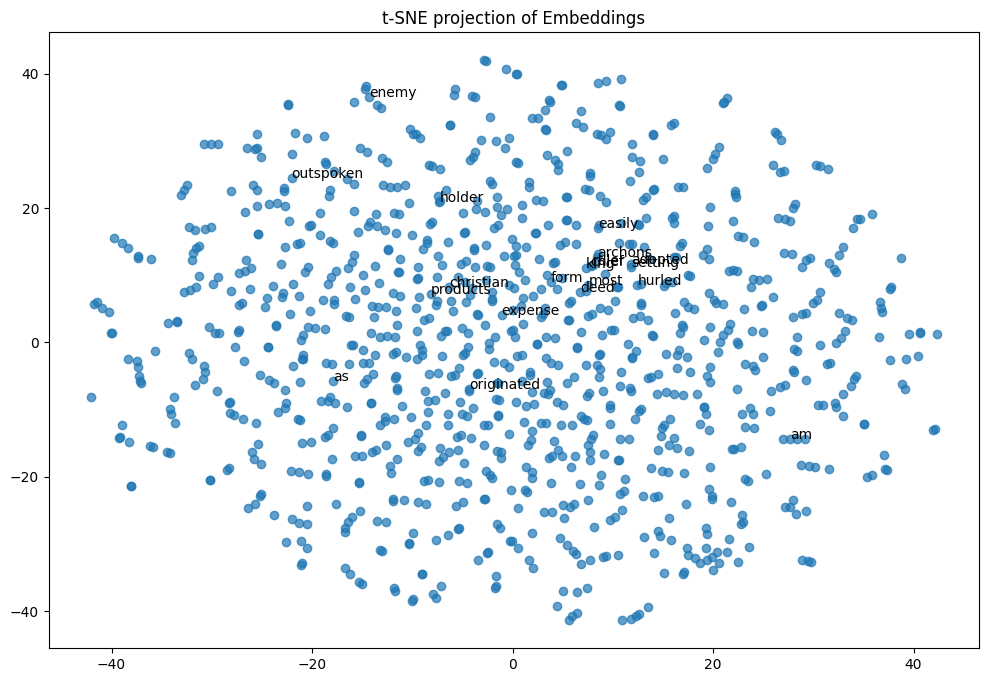

In [79]:
viz_nearest_words(top_nearest_words('king', 20))

In [80]:
top_nearest_words('king', 20)

['king',
 'chief',
 'ruler',
 'holder',
 'form',
 'adopted',
 'setting',
 'most',
 'originated',
 'products',
 'christian',
 'as',
 'archons',
 'outspoken',
 'hurled',
 'enemy',
 'expense',
 'easily',
 'deed',
 'am']